Chapter 1: Exploratory Data Analysis

Nama: [Qaris Faras]

NIM: [101032300247]

Referensi: Practical Statistics for Data Scientists, Second Edition — Peter Bruce, Andrew Bruce, dan Peter Gedeck (2020).

Pengantar

Exploratory Data Analysis (EDA) adalah tahap awal untuk memahami karakteristik data melalui ringkasan statistik dan visualisasi. Bab ini membahas jenis data, ukuran pemusatan, ukuran penyebaran, distribusi data, serta hubungan antarvariabel.

Notebook ini digunakan untuk mereproduksi contoh kode Bab 1, menjelaskan konsep teorinya, dan menginterpretasikan hasil yang diperoleh.

1. Elements of Structured Data — Jenis Data Terstruktur

Data terstruktur adalah data yang disusun secara teratur, misalnya dalam tabel dengan baris dan kolom. Dua jenis dasarnya adalah data numerik dan data kategorikal.

Data numerik menunjukkan jumlah atau besaran yang dapat dihitung atau diukur. Data ini terdiri atas:
- Diskret: memiliki nilai yang terpisah, misalnya jumlah kendaraan.
- Kontinu: dapat mengambil nilai dalam suatu rentang, misalnya berat badan atau kecepatan angin.

Data kategorikal menunjukkan kelompok atau kategori. Contohnya adalah jenis kendaraan. Beberapa bentuknya meliputi:
- Nominal: kategori tanpa urutan, misalnya warna kendaraan.
- Ordinal: kategori yang memiliki urutan, misalnya tingkat pendidikan.
- Biner: hanya memiliki dua kemungkinan, misalnya ya/tidak atau benar/salah.

Memahami jenis data membantu kita memilih perhitungan, grafik, dan metode analisis yang sesuai. Angka yang digunakan sebagai kode kategori tidak otomatis menjadi data numerik; maknanya perlu diperhatikan.

In [1]:
import pandas as pd

# Membaca data contoh dari buku
url = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/state.csv"
state = pd.read_csv(url)

# Menampilkan 5 baris pertama
state.head()

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


2. Rectangular Data — Data Berbentuk Tabel

Rectangular data adalah data dua dimensi yang tersusun dalam baris dan kolom. Setiap baris menunjukkan satu pengamatan atau record, sedangkan setiap kolom menunjukkan satu variabel.

Dalam pandas, struktur tabel ini disebut DataFrame. Pada dataset state, setiap baris mewakili satu negara bagian di Amerika Serikat.

| Kolom | Makna | Jenis data |
|---|---|---|
| State | Nama negara bagian | Kategorikal nominal |
| Population | Jumlah penduduk | Numerik diskret |
| Murder.Rate | Angka pembunuhan per 100.000 penduduk per tahun | Numerik kontinu |
| Abbreviation | Singkatan nama negara bagian | Kategorikal nominal |

DataFrame juga memiliki index sebagai label baris. Angka 0–4 di sebelah kiri hasil merupakan index, bukan kolom tambahan dalam dataset.

Interpretasi Hasil

Perintah state.head() menampilkan lima baris pertama agar struktur dan isi data dapat diperiksa sebelum analisis. Perintah ini tidak membatasi keseluruhan dataset menjadi lima baris.

Selain bentuk tabel, terdapat struktur data deret waktu untuk pengukuran berurutan, data spasial untuk informasi lokasi, serta data jaringan untuk hubungan antarobjek.

3. Estimates of Location — Ukuran Pemusatan

3.1 Mean (Rata-rata)

Ukuran pemusatan digunakan untuk merangkum letak pusat data numerik. Salah satu ukurannya adalah mean.

Mean dihitung dengan menjumlahkan seluruh nilai, kemudian membaginya dengan jumlah data.

Rumus: mean = jumlah seluruh nilai ÷ jumlah data.

Contoh: mean dari 3, 5, 1, dan 2 adalah (3 + 5 + 1 + 2) ÷ 4 = 2,75.

Mean menggunakan seluruh nilai sehingga dapat dipengaruhi oleh nilai yang sangat besar atau sangat kecil. Pada contoh berikut, mean digunakan untuk menghitung rata-rata jumlah penduduk per negara bagian.

In [2]:
# Menghitung rata-rata kolom Population
mean_population = state["Population"].mean()

print("Rata-rata jumlah penduduk:", mean_population)

Rata-rata jumlah penduduk: 6162876.3


3.2 Median (Nilai Tengah)

Median adalah nilai tengah setelah data diurutkan dari yang terkecil hingga terbesar.

Jika jumlah data ganjil, median adalah nilai tepat di tengah. Jika jumlah data genap, median adalah rata-rata dari dua nilai tengah.

Contoh: data 1, 2, 3, dan 5 memiliki median (2 + 3) ÷ 2 = 2,5.

Median merupakan ukuran pemusatan yang robust, yaitu lebih tahan terhadap pengaruh nilai ekstrem. Nilai yang sangat jauh dari sebagian besar data disebut outlier. Dibandingkan mean, median lebih sedikit dipengaruhi oleh besarnya nilai ekstrem.

In [3]:
median_population = state["Population"].median()

print("Median jumlah penduduk:", median_population)

Median jumlah penduduk: 4436369.5


Interpretasi Hasil

Median jumlah penduduk adalah 4.436.369,5 atau sekitar 4,44 juta orang. Dalam dataset ini, separuh negara bagian memiliki jumlah penduduk di bawah median dan separuh lainnya di atas median.

Median lebih kecil daripada mean yang sekitar 6,16 juta orang. Beberapa negara bagian berpenduduk sangat besar menaikkan mean, sedangkan median lebih tahan terhadap pengaruh nilai tersebut.

3.3 Trimmed Mean — Rata-rata Terpangkas

Trimmed mean dihitung dengan mengurutkan data, memangkas sebagian nilai pada kedua ujung, lalu menghitung rata-rata nilai yang tersisa. Tujuannya adalah mengurangi pengaruh nilai ekstrem.

Dalam contoh buku, digunakan pemangkasan 10% pada setiap ujung. Karena terdapat 50 negara bagian, sebanyak 5 nilai terkecil dan 5 nilai terbesar dikeluarkan dari perhitungan. Rata-rata kemudian dihitung dari 40 nilai yang tersisa.

Pemangkasan 10% pada setiap ujung berarti total 20% nilai dikeluarkan dari perhitungan.

In [4]:
from scipy.stats import trim_mean

trimmed_mean_population = trim_mean(state["Population"], 0.1)

print("Trimmed mean jumlah penduduk:", trimmed_mean_population)

Trimmed mean jumlah penduduk: 4783697.125


Interpretasi dan Perbandingan Hasil

| Ukuran pemusatan | Hasil jumlah penduduk |
|---|---:|
| Mean | 6.162.876,3 |
| Trimmed mean 10% per ujung | 4.783.697,125 |
| Median | 4.436.369,5 |

Trimmed mean menghasilkan nilai sekitar 4,78 juta orang per negara bagian, berada di antara mean dan median. Pemangkasan mengurangi pengaruh nilai ekstrem sambil tetap menggunakan sebagian besar pengamatan.

3.4 Weighted Mean — Rata-rata Tertimbang

Weighted mean adalah rata-rata yang memberikan bobot pada setiap nilai. Nilai dengan bobot lebih besar memberikan kontribusi lebih besar terhadap hasil.

Rumus: weighted mean = jumlah (nilai × bobot) ÷ jumlah seluruh bobot.

Dalam contoh buku, nilai yang dihitung berasal dari kolom Murder.Rate, sedangkan bobotnya berasal dari kolom Population. Dengan demikian, negara bagian berpenduduk lebih besar memiliki pengaruh lebih besar dalam perhitungan rata-rata angka pembunuhan.

Pembobotan juga dapat digunakan untuk menyesuaikan keterwakilan kelompok atau perbedaan keandalan pengukuran.

In [5]:
import numpy as np

weighted_mean_murder = np.average(
    state["Murder.Rate"],
    weights=state["Population"]
)

print("Rata-rata tertimbang angka pembunuhan:", round(weighted_mean_murder, 6))

Rata-rata tertimbang angka pembunuhan: 4.445834


Interpretasi Hasil

Rata-rata tertimbang angka pembunuhan pada dataset historis buku adalah sekitar 4,45 kejadian per 100.000 penduduk per tahun.

Hasil ini memperhitungkan perbedaan jumlah penduduk antarnegara bagian. Negara bagian berpenduduk besar mendapatkan bobot lebih besar dalam perhitungan.

3.5 Weighted Median — Median Tertimbang

Weighted median adalah ukuran nilai tengah yang mempertimbangkan bobot setiap pengamatan. Data diurutkan, kemudian posisi tengah ditentukan berdasarkan penjumlahan bobot secara kumulatif.

Dalam implementasi buku, paket wquantiles menghitung median sebagai kuantil tertimbang 0,5 menggunakan interpolasi.

Pada contoh ini, nilai yang digunakan berasal dari Murder.Rate, sedangkan bobotnya berasal dari Population. Negara bagian berpenduduk lebih besar memiliki porsi bobot lebih besar dalam penentuan nilai tengah.

In [6]:
%pip -q install wquantiles==0.6

import wquantiles

weighted_median_murder = wquantiles.median(
    state["Murder.Rate"],
    weights=state["Population"]
)

print("Median tertimbang angka pembunuhan:", weighted_median_murder)

Median tertimbang angka pembunuhan: 4.4


Interpretasi Hasil

Median tertimbang angka pembunuhan pada dataset buku adalah 4,4 kejadian per 100.000 penduduk per tahun, dengan jumlah penduduk sebagai bobot.

Hasil ini mendekati weighted mean yang sekitar 4,45. Pada dataset ini, kedua ukuran tersebut memberikan nilai pusat yang relatif dekat.

## 4. Estimates of Variability — Ukuran Penyebaran

Ukuran penyebaran menjelaskan seberapa bervariasi nilai-nilai dalam suatu data. Dua kumpulan data bisa memiliki rata-rata yang sama, tetapi penyebarannya berbeda.

### 4.1 Standard Deviation — Standar Deviasi

Standar deviasi mengukur penyebaran data terhadap rata-ratanya. Semakin besar nilainya, semakin besar variasi dalam data.

Perhitungannya dimulai dengan mencari selisih setiap nilai terhadap rata-rata, menguadratkan selisih tersebut, kemudian menjumlahkannya. Dalam rumus sampel, jumlah ini dibagi dengan \(n-1\) untuk mendapatkan varians. Akar kuadrat varians menghasilkan standar deviasi.

Standar deviasi memiliki satuan yang sama dengan data asal, yaitu orang untuk kolom Population. Ukuran ini sensitif terhadap nilai ekstrem karena selisihnya dikuadratkan.

In [7]:
std_population = state["Population"].std(ddof=1)

print("Standar deviasi jumlah penduduk:", round(std_population, 2))

Standar deviasi jumlah penduduk: 6848235.35


### Interpretasi Hasil

Standar deviasi jumlah penduduk adalah sekitar 6,85 juta orang. Dibandingkan dengan rata-rata sekitar 6,16 juta orang, nilai ini menunjukkan bahwa jumlah penduduk antarnegara bagian memiliki variasi yang besar.

Negara bagian dengan jumlah penduduk sangat besar dapat meningkatkan standar deviasi karena ukuran ini sensitif terhadap nilai ekstrem.

### 4.2 Interquartile Range — Rentang Antarkuartil

Interquartile Range (IQR) mengukur rentang 50% bagian tengah data.

Setelah data diurutkan dari terkecil hingga terbesar, kuartil membagi data menjadi empat bagian:

- Q1 adalah kuartil pertama atau persentil ke-25.
- Q2 adalah kuartil kedua atau median, yaitu persentil ke-50.
- Q3 adalah kuartil ketiga atau persentil ke-75.

IQR dihitung dengan rumus:

**IQR = Q3 − Q1**

Semakin besar IQR, semakin lebar penyebaran bagian tengah data. IQR lebih tahan terhadap nilai ekstrem karena menggunakan batas kuartil, bukan nilai terkecil dan terbesar.

In [8]:
q1 = state["Population"].quantile(0.25)
q3 = state["Population"].quantile(0.75)

iqr_population = q3 - q1

print("Q1:", q1)
print("Q3:", q3)
print("IQR jumlah penduduk:", iqr_population)

Q1: 1833004.25
Q3: 6680312.25
IQR jumlah penduduk: 4847308.0


### Interpretasi Hasil

Kuartil pertama jumlah penduduk adalah sekitar 1,83 juta orang, sedangkan kuartil ketiganya sekitar 6,68 juta orang.

Dengan demikian, 50% bagian tengah data jumlah penduduk berada di antara kedua batas tersebut. Lebar rentangnya, yaitu IQR, adalah 4.847.308 orang atau sekitar 4,85 juta orang.

### 4.3 Median Absolute Deviation — MAD

MAD mengukur penyebaran data dengan menggunakan median. Ukuran ini lebih tahan terhadap nilai ekstrem dibandingkan standar deviasi.

Langkah perhitungan MAD dasar:

1. Hitung median data.
2. Hitung nilai absolut selisih setiap data terhadap median tersebut.
3. Ambil median dari seluruh selisih absolut.

Nilai absolut membuat selisih negatif menjadi positif, sehingga penyimpangan tidak saling menghapus.

Fungsi yang digunakan dalam contoh buku menghasilkan MAD yang sudah disesuaikan: MAD dasar dikalikan faktor sekitar 1,4826. Faktor ini membuat skalanya sebanding dengan standar deviasi ketika data berdistribusi normal.

In [9]:
%pip -q install statsmodels

from statsmodels import robust

median_population = state["Population"].median()

mad_raw_population = (
    state["Population"] - median_population
).abs().median()

mad_population = robust.scale.mad(state["Population"])

print("MAD tanpa penyesuaian:", mad_raw_population)
print("MAD setelah penyesuaian:", round(mad_population, 2))

MAD tanpa penyesuaian: 2596702.0
MAD setelah penyesuaian: 3849876.15


### Interpretasi Hasil

MAD tanpa penyesuaian adalah 2.596.702 orang. Artinya, median jarak absolut jumlah penduduk terhadap median jumlah penduduk adalah sekitar 2,60 juta orang.

Setelah penyesuaian, MAD menjadi sekitar 3,85 juta orang. Hasil ini lebih kecil daripada standar deviasi sebelumnya, yaitu sekitar 6,85 juta orang. MAD memberikan ukuran penyebaran yang lebih tahan terhadap pengaruh negara bagian dengan jumlah penduduk ekstrem.

### 4.4 Mean Absolute Deviation — Rata-rata Penyimpangan Absolut

Mean absolute deviation mengukur rata-rata jarak absolut setiap nilai terhadap rata-rata data.

Langkah perhitungannya:

1. Hitung rata-rata data.
2. Hitung nilai absolut selisih setiap nilai terhadap rata-rata tersebut.
3. Jumlahkan seluruh selisih absolut, kemudian bagi dengan jumlah data, yaitu n.

Penggunaan nilai absolut mencegah selisih negatif dan positif saling menghapus.

Mean absolute deviation menggunakan rata-rata sebagai pusat dan merata-ratakan selisih absolut. Sementara itu, median absolute deviation menggunakan median sebagai pusat dan mengambil median selisih absolut.

Mean absolute deviation tetap sensitif terhadap nilai ekstrem karena menggunakan rata-rata.

In [10]:
mean_population = state["Population"].mean()

mean_abs_deviation_population = (
    state["Population"] - mean_population
).abs().mean()

print(
    "Mean absolute deviation:",
    round(mean_abs_deviation_population, 2)
)

Mean absolute deviation: 4450933.36


### Interpretasi Hasil

Mean absolute deviation jumlah penduduk adalah sekitar 4,45 juta orang.

Artinya, rata-rata jarak absolut jumlah penduduk setiap negara bagian terhadap rata-rata jumlah penduduk adalah sekitar 4,45 juta orang. Hasil ini menunjukkan adanya variasi yang besar dalam jumlah penduduk antarnegara bagian.

## 5. Exploring the Data Distribution — Memahami Distribusi Data

Distribusi data menggambarkan bagaimana nilai-nilai tersebar, termasuk bagian tengah serta bagian dengan nilai rendah dan tinggi.

### 5.1 Percentiles — Persentil

Persentil menunjukkan batas posisi tertentu setelah data diurutkan dari terkecil hingga terbesar.

Persentil ke-50 adalah median. Kuartil menggunakan persentil ke-25, ke-50, dan ke-75. Desil menggunakan batas persentil ke-10, ke-20, hingga ke-90.

Persentil membantu kita memahami penyebaran data lebih lengkap daripada hanya melihat rata-rata.

Pada contoh ini, kita menghitung persentil kolom Murder.Rate, yaitu angka pembunuhan tahunan per 100.000 penduduk. Setiap negara bagian mempunyai bobot yang sama dalam perhitungan.

In [11]:
percentiles_murder = state["Murder.Rate"].quantile(
    [0.05, 0.25, 0.50, 0.75, 0.95]
)

print(percentiles_murder)

0.05    1.600
0.25    2.425
0.50    4.000
0.75    5.550
0.95    6.510
Name: Murder.Rate, dtype: float64


### Interpretasi Hasil

Median angka pembunuhan adalah 4 per 100.000 penduduk per tahun.

Persentil ke-25 sebesar 2,425 dan persentil ke-75 sebesar 5,55 menunjukkan batas 50% bagian tengah data.

Persentil ke-5 sebesar 1,6 dan persentil ke-95 sebesar 6,51 memberikan gambaran nilai pada bagian bawah dan atas distribusi. Hasil ini menunjukkan variasi angka pembunuhan antarnegara bagian.

### 5.2 Boxplot — Diagram Kotak

Boxplot merangkum distribusi data melalui median, kuartil, dan pencilan.

Cara membaca boxplot vertikal:

- Batas bawah kotak menunjukkan Q1.
- Batas atas kotak menunjukkan Q3. Kotak mencakup 50% bagian tengah data.
- Garis horizontal di dalam kotak menunjukkan median.
- Whisker atau garis yang keluar dari kotak menjangkau nilai terjauh yang masih berada dalam batas Q1 − 1,5 × IQR dan Q3 + 1,5 × IQR.
- Titik di luar whisker menunjukkan observasi yang ditandai sebagai pencilan menurut aturan tersebut.

Pada contoh ini, jumlah penduduk dibagi 1.000.000 agar sumbu vertikal menggunakan satuan juta orang.

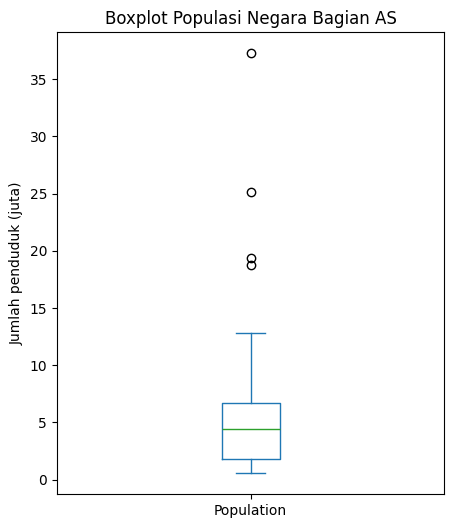

In [12]:
import matplotlib.pyplot as plt

ax = (state["Population"] / 1_000_000).plot.box(
    figsize=(5, 6)
)

ax.set_ylabel("Jumlah penduduk (juta)")
ax.set_title("Boxplot Populasi Negara Bagian AS")

plt.show()

### Interpretasi Hasil

Median jumlah penduduk berada di sekitar 4,44 juta orang. Kotak membentang dari sekitar 1,83 juta hingga 6,68 juta orang, sesuai Q1 dan Q3 yang telah dihitung sebelumnya.

Empat titik di bagian atas menunjukkan negara bagian dengan jumlah penduduk yang jauh lebih besar dibandingkan sebagian besar negara bagian lainnya.

Distribusi cenderung miring ke kanan, yaitu memiliki ekor ke arah nilai jumlah penduduk yang besar.

### 5.3 Frequency Table — Tabel Frekuensi

Tabel frekuensi merangkum data dengan membagi rentang nilainya menjadi beberapa interval atau bins. Frekuensi menunjukkan jumlah observasi dalam setiap interval.

Pada contoh ini, jumlah penduduk dibagi menjadi 10 interval dengan lebar yang sama. Jumlah negara bagian pada setiap interval dapat berbeda.

Interval kosong tetap ditampilkan karena menunjukkan bagian rentang yang tidak memiliki observasi.

Pemilihan jumlah interval memengaruhi informasi yang terlihat. Terlalu sedikit interval dapat menyembunyikan pola, sedangkan terlalu banyak interval dapat membuat ringkasan terlalu terperinci.

In [13]:
binned_population = pd.cut(state["Population"], bins=10)

population_frequency = (
    binned_population.value_counts().sort_index()
)

print(population_frequency)

Population
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
(33584923.0, 37253956.0]     1
Name: count, dtype: int64


### Interpretasi Hasil

Interval pertama berisi 24 negara bagian, dengan jumlah penduduk hingga sekitar 4,23 juta orang. Interval kedua berisi 14 negara bagian.

Dua interval, yaitu interval kedelapan dan kesembilan, memiliki frekuensi nol. Interval terakhir hanya berisi satu negara bagian.

Hasil ini menunjukkan bahwa data terkonsentrasi pada jumlah penduduk yang lebih rendah, sementara hanya sedikit negara bagian memiliki jumlah penduduk sangat besar.

### 5.4 Histogram

Histogram menampilkan distribusi data numerik melalui batang-batang yang mewakili interval atau bins.

Cara membaca histogram pada contoh ini:

- Sumbu horizontal menunjukkan jumlah penduduk dalam juta orang.
- Sumbu vertikal menunjukkan jumlah negara bagian.
- Tinggi setiap batang menunjukkan frekuensi dalam interval tersebut.

Batang pada interval yang berurutan saling berdampingan. Interval kosong tetap memiliki tempat pada sumbu horizontal, dengan frekuensi nol.

Histogram membantu kita melihat konsentrasi data, penyebaran, dan kemiringan distribusi. Bentuknya dapat berubah ketika jumlah interval diubah.

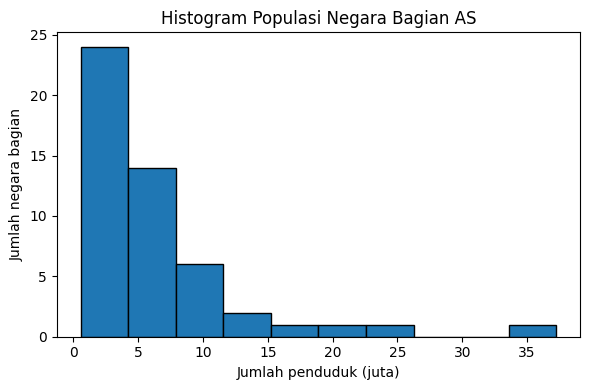

In [14]:
import matplotlib.pyplot as plt

ax = (state["Population"] / 1_000_000).plot.hist(
    bins=10,
    figsize=(6, 4),
    edgecolor="black"
)

ax.set_xlabel("Jumlah penduduk (juta)")
ax.set_ylabel("Jumlah negara bagian")
ax.set_title("Histogram Populasi Negara Bagian AS")

plt.tight_layout()
plt.show()

### Interpretasi Hasil

Batang pertama memiliki frekuensi 24 negara bagian, sedangkan batang kedua memiliki frekuensi 14 negara bagian. Data banyak terkonsentrasi pada jumlah penduduk yang lebih rendah.

Hanya sedikit negara bagian memiliki jumlah penduduk sangat besar. Hal ini membentuk ekor ke arah kanan, sehingga distribusi jumlah penduduk miring ke kanan atau positively skewed.

Pola ini sesuai dengan boxplot sebelumnya yang menunjukkan beberapa pencilan pada jumlah penduduk tinggi.

### 5.5 Statistical Moments — Skewness dan Kurtosis

Momen statistik membantu menjelaskan karakteristik distribusi. Mean menggambarkan pusat data, varians menggambarkan penyebaran, sedangkan skewness dan kurtosis menjelaskan bentuk distribusi.

**Skewness — Kemiringan Distribusi**

Skewness menggambarkan kecenderungan distribusi memiliki ekor lebih panjang pada salah satu sisi.

- Skewness positif: ekor memanjang ke arah nilai besar atau ke kanan.
- Skewness negatif: ekor memanjang ke arah nilai kecil atau ke kiri.
- Skewness mendekati nol: kemiringan berdasarkan ukuran ini relatif kecil.

Pada histogram jumlah penduduk, sebagian besar negara bagian berada pada nilai rendah, sementara beberapa memiliki jumlah penduduk sangat besar. Pola tersebut menunjukkan kemiringan ke kanan.

**Kurtosis — Kecenderungan Nilai Ekstrem**

Kurtosis berkaitan dengan pengaruh nilai-nilai yang jauh dari pusat distribusi. Ukuran ini menggunakan pangkat empat dari penyimpangan yang kemudian distandarisasi, sehingga nilai ekstrem memiliki pengaruh besar.

Ada dua konvensi pelaporan:

- Kurtosis Pearson: distribusi normal memiliki nilai 3.
- Excess kurtosis atau Fisher: distribusi normal memiliki nilai 0, karena nilai Pearson dikurangi 3.

Konvensi yang digunakan perlu disebutkan ketika melaporkan hasil. Histogram dan boxplot membantu kita menilai bentuk distribusi secara visual.

### 5.6 Density Plots and Estimates — Estimasi Kepadatan

Density plot menggambarkan distribusi data melalui kurva halus. Kurva ini dapat dihitung menggunakan Kernel Density Estimation (KDE), yang menggabungkan kernel pada setiap observasi menjadi estimasi kepadatan.

Bandwidth mengatur tingkat kehalusan kurva. Bandwidth kecil menghasilkan lebih banyak lekukan, sedangkan bandwidth besar menghasilkan kurva lebih halus.

Pada grafik ini, histogram menggunakan density=True agar skalanya sesuai dengan kurva KDE. Sumbu vertikal menunjukkan kepadatan.

Luas keseluruhan di bawah kurva kepadatan adalah 1. Luas pada suatu interval menunjukkan estimasi proporsi data dalam interval tersebut.

Penyesuaian contoh buku: batas histogram dimulai dari 0 agar nilai angka pembunuhan 0,9 ikut tercakup.

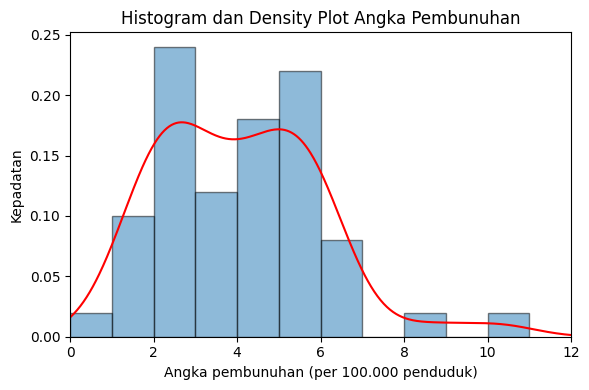

In [15]:
import matplotlib.pyplot as plt

ax = state["Murder.Rate"].plot.hist(
    bins=range(0, 12),
    density=True,
    alpha=0.5,
    edgecolor="black",
    figsize=(6, 4)
)

state["Murder.Rate"].plot.density(ax=ax, color="red")

ax.set_xlim(0, 12)
ax.set_xlabel("Angka pembunuhan (per 100.000 penduduk)")
ax.set_ylabel("Kepadatan")
ax.set_title("Histogram dan Density Plot Angka Pembunuhan")

plt.tight_layout()
plt.show()

### Interpretasi Hasil

Histogram menunjukkan distribusi angka pembunuhan dalam interval, sedangkan kurva merah memberikan estimasi distribusi yang lebih halus.

Bagian kurva yang lebih tinggi menunjukkan konsentrasi data yang lebih besar. Sebagian besar observasi berada pada angka pembunuhan sekitar 2–6 per 100.000 penduduk per tahun, dengan beberapa nilai lebih tinggi yang memanjangkan ekor ke kanan.

Luas di bawah kurva pada suatu interval digunakan untuk memperkirakan proporsi data, sedangkan tinggi kurva menunjukkan kepadatan.

## 6. Exploring Binary and Categorical Data

Data kategorikal menunjukkan kelompok atau label, seperti penyebab keterlambatan penerbangan. Data biner merupakan bentuk khusus data kategorikal dengan dua kemungkinan, misalnya terlambat dan tidak terlambat.

### 6.1 Bar Chart — Diagram Batang

Diagram batang membandingkan frekuensi atau proporsi antar kategori. Sumbu horizontal menunjukkan kategori, sedangkan sumbu vertikal menunjukkan nilainya.

Contoh buku menggunakan data keterlambatan penerbangan di Dallas/Fort Worth (DFW), dengan kategori:

| Kategori | Makna |
|---|---|
| Carrier | Faktor dalam kendali maskapai |
| ATC | Sistem pengaturan lalu lintas udara |
| Weather | Cuaca |
| Security | Keamanan |
| Inbound | Pesawat yang akan digunakan datang terlambat |

Pada diagram batang, batang diberi jarak untuk membedakan kategori. Histogram merangkum data numerik ke dalam interval.

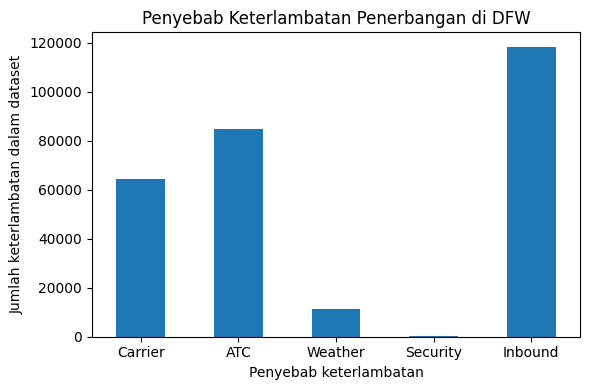

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

url_dfw = (
    "https://raw.githubusercontent.com/gedeck/"
    "practical-statistics-for-data-scientists/master/data/dfw_airline.csv"
)

dfw = pd.read_csv(url_dfw)

ax = dfw.transpose().plot.bar(
    figsize=(6, 4),
    legend=False,
    rot=0
)

ax.set_xlabel("Penyebab keterlambatan")
ax.set_ylabel("Jumlah keterlambatan dalam dataset")
ax.set_title("Penyebab Keterlambatan Penerbangan di DFW")

plt.tight_layout()
plt.show()

### Interpretasi Hasil

Kategori Inbound memiliki nilai terbesar. Ini menunjukkan bahwa pesawat yang datang terlambat merupakan penyebab keterlambatan paling dominan dalam dataset.

Kategori ATC dan Carrier juga memiliki kontribusi besar, sementara Security memiliki kontribusi terkecil.

Diagram batang memudahkan perbandingan penyebab keterlambatan melalui tinggi masing-masing batang.

### 6.2 Proportions and Percentages — Proporsi dan Persentase

Proporsi menunjukkan bagian suatu kategori terhadap total frekuensi seluruh kategori.

**Proporsi = frekuensi kategori ÷ total frekuensi**

Persentase diperoleh dengan mengalikan proporsi dengan 100.

**Persentase = proporsi × 100%**

Pada contoh DFW, persentase menunjukkan komposisi penyebab keterlambatan yang dirangkum dalam dataset. Seluruh kategori bersama-sama membentuk 100% dari total tersebut.

Persentase memudahkan kita membandingkan kontribusi setiap penyebab keterlambatan.

In [17]:
delay_totals = dfw.iloc[0]

delay_proportions = delay_totals / delay_totals.sum()

delay_percentages = delay_proportions * 100

print(delay_percentages.round(2))

Carrier     23.02
ATC         30.40
Weather      4.03
Security     0.12
Inbound     42.43
Name: 0, dtype: float64


### Interpretasi Hasil

Inbound memiliki kontribusi terbesar, yaitu sekitar 42,43% dari total frekuensi penyebab keterlambatan dalam dataset.

ATC menyumbang sekitar 30,40%, sedangkan Carrier menyumbang sekitar 23,02%. Weather dan Security memiliki kontribusi lebih kecil, masing-masing sekitar 4,03% dan 0,12%.

Hasil persentase ini memperjelas pola yang terlihat pada diagram batang sebelumnya.

### 6.3 Mode — Modus

Modus adalah nilai atau kategori yang paling sering muncul dalam suatu dataset.

Untuk data kategorikal, modus membantu kita mengetahui kategori dengan frekuensi tertinggi. Sebagai contoh, pada data keterlambatan penerbangan, modus menunjukkan penyebab keterlambatan yang paling sering terjadi.

Jika beberapa kategori memiliki frekuensi tertinggi yang sama, semuanya merupakan modus.

Dataset DFW sudah berisi ringkasan frekuensi setiap penyebab keterlambatan. Karena itu, kita mencari kategori dengan frekuensi terbesar.

In [18]:
delay_totals = dfw.iloc[0]

mode_delay = delay_totals.idxmax()

print("Modus penyebab keterlambatan:", mode_delay)

Modus penyebab keterlambatan: Inbound


**Interpretasi hasil:**

Modus penyebab keterlambatan adalah **Inbound**, yaitu keterlambatan karena pesawat yang akan digunakan tiba terlambat dari penerbangan sebelumnya.

Kategori Inbound menyumbang sekitar **42,43%** dari total frekuensi penyebab keterlambatan dalam dataset. Persentase ini merupakan yang terbesar di antara lima kategori, sehingga Inbound menjadi modus.

### 6.4 Expected Value — Nilai Harapan

Nilai harapan adalah rata-rata teoretis suatu hasil yang dihitung berdasarkan peluang setiap kemungkinan.

Nilai harapan merupakan bentuk weighted mean, dengan probabilitas sebagai bobotnya. Untuk hasil yang diskret, rumusnya:

$$
E(X) = \sum_i p_i x_i
$$

Di sini, \(x_i\) adalah nilai hasil dan \(p_i\) adalah peluang hasil tersebut. Jumlah peluang seluruh kemungkinan harus sama dengan 1 atau 100%.

Dalam contoh buku, perusahaan menawarkan layanan cloud kepada peserta webinar dengan asumsi:

- **5%** peserta membeli layanan seharga **300 dolar per bulan**.
- **15%** peserta membeli layanan seharga **50 dolar per bulan**.
- **80%** peserta tidak membeli layanan, sehingga pendapatannya **0 dolar**.

Untuk menghitung nilai harapan pendapatan per peserta, kita mengalikan setiap pendapatan dengan peluangnya, kemudian menjumlahkan hasilnya.

In [19]:
expected_value = (
    0.05 * 300
    + 0.15 * 50
    + 0.80 * 0
)

print(f"Nilai harapan: ${expected_value:.2f} per peserta per bulan")

Nilai harapan: $22.50 per peserta per bulan


**Interpretasi hasil:**

Berdasarkan peluang yang diasumsikan, nilai harapan pendapatan adalah **22,50 dolar per peserta per bulan**.

Angka ini menggambarkan rata-rata teoretis apabila skenario tersebut terjadi berulang kali pada banyak peserta. Pendapatan dari masing-masing peserta tetap mengikuti salah satu kemungkinan: 300 dolar, 50 dolar, atau 0 dolar.

Perhitungan ini menunjukkan pendapatan sebelum dikurangi biaya.

### 6.5 Probability — Probabilitas

Probabilitas adalah ukuran peluang terjadinya suatu kejadian. Nilainya berada antara **0 dan 1**, atau **0% dan 100%**.

Dalam pendekatan frekuensi, probabilitas menggambarkan proporsi kemunculan suatu kejadian apabila situasi yang sama dapat diulang sangat banyak kali.

**Odds** membandingkan peluang suatu kejadian terjadi dengan peluang kejadian tersebut tidak terjadi.

Sebagai contoh, odds yang **mendukung kemenangan sebesar 2:1** berarti perbandingan peluang menang terhadap tidak menang adalah 2 banding 1.

Untuk odds yang mendukung kejadian sebesar \(a:b\), probabilitasnya dihitung dengan:

$$
P = \frac{a}{a+b}
$$

Dengan demikian, probabilitas menang pada contoh tersebut adalah:

$$
P(\text{menang}) = \frac{2}{2+1} = \frac{2}{3}
$$

In [20]:
odds_win = 2
odds_not_win = 1

probability_win = odds_win / (odds_win + odds_not_win)

print(f"Probabilitas menang: {probability_win:.4f}")
print(f"Persentase peluang menang: {probability_win * 100:.2f}%")

Probabilitas menang: 0.6667
Persentase peluang menang: 66.67%


**Interpretasi hasil:**

Odds yang mendukung kemenangan sebesar **2:1** menghasilkan probabilitas menang sekitar **0,6667**, atau **66,67%**. Peluang tidak menang adalah sekitar **33,33%**.

Probabilitas tersebut menunjukkan bahwa menang lebih mungkin terjadi. Namun, hasil satu pertandingan masih dapat berupa menang atau tidak menang; probabilitas tidak menjamin hasil pertandingan tertentu.

## 7. Correlation — Korelasi

### 7.1 Pearson Correlation — Korelasi Pearson

Korelasi Pearson mengukur arah dan kekuatan **hubungan linear** antara dua variabel numerik. Nilai koefisiennya, disebut \(r\), berada antara −1 dan +1.

- **r = +1:** hubungan linear positif sempurna.
- **r = −1:** hubungan linear negatif sempurna.
- **r = 0:** tidak ada hubungan linear, meskipun hubungan non-linear masih dapat terjadi.

Semakin mendekati +1 atau −1, semakin kuat hubungan linearnya. Tanda positif menunjukkan kecenderungan bergerak searah, sedangkan tanda negatif menunjukkan kecenderungan bergerak berlawanan arah.

Rumus korelasi Pearson adalah:

$$
r = \frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{(n-1)s_xs_y}
$$

Di sini, \(n\) adalah jumlah pasangan pengamatan, \(\bar{x}\) dan \(\bar{y}\) adalah rata-rata masing-masing variabel, serta \(s_x\) dan \(s_y\) adalah standar deviasi sampelnya.

Korelasi Pearson sensitif terhadap outlier. Kesimpulan tentang hubungan sebab-akibat memerlukan bukti tambahan.

In [21]:
import pandas as pd

v1 = pd.Series([1, 2, 3])
v2 = pd.Series([4, 5, 6])

pearson_correlation = v1.corr(v2, method="pearson")

print(f"Korelasi Pearson: {pearson_correlation:.2f}")

Korelasi Pearson: 1.00


**Interpretasi hasil:**

Nilai korelasi Pearson sebesar **1,00** menunjukkan hubungan linear positif sempurna antara `v1` dan `v2`.

Pada contoh ini, setiap nilai `v2` sama dengan nilai `v1` ditambah 3. Ketika `v1` meningkat sebesar 1, `v2` juga meningkat sebesar 1. Karena seluruh pasangan mengikuti pola garis lurus yang meningkat, korelasinya bernilai +1.

### 7.2 Correlation Matrix — Matriks Korelasi

Matriks korelasi adalah tabel yang menunjukkan korelasi antara setiap pasangan variabel numerik.

Cara membacanya:

- Nama variabel muncul pada baris dan kolom.
- Setiap sel menunjukkan korelasi antara variabel pada baris dan kolom tersebut.
- Diagonal bernilai **1** karena setiap variabel yang memiliki variasi berkorelasi sempurna dengan dirinya sendiri.
- Matriks bersifat **simetris**: korelasi X dengan Y sama dengan korelasi Y dengan X.

Pada contoh buku, kita menggunakan data perubahan harga harian beberapa **ETF (exchange-traded funds)**, yaitu dana investasi yang diperdagangkan di bursa.

Kita memilih data setelah 1 Juli 2012, lalu menghitung korelasi Pearson untuk setiap pasangan ETF.

In [22]:
import pandas as pd

base_url = (
    "https://raw.githubusercontent.com/gedeck/"
    "practical-statistics-for-data-scientists/master/data/"
)

sp500_px = pd.read_csv(
    base_url + "sp500_data.csv.gz",
    compression="gzip",
    index_col=0,
    parse_dates=True
)

sp500_sym = pd.read_csv(base_url + "sp500_sectors.csv")

etf_symbols = sp500_sym.loc[
    sp500_sym["sector"] == "etf", "symbol"
]

etfs = sp500_px.loc[
    sp500_px.index > "2012-07-01", etf_symbols
]

correlation_matrix = etfs.corr(method="pearson")

correlation_matrix.round(3)

,XLI,QQQ,SPY,DIA,GLD,VXX,USO,IWM,XLE,XLY,XLU,XLB,XTL,XLV,XLP,XLF,XLK
XLI,1.000,0.786,0.889,0.870,0.057,-0.468,0.237,0.782,0.650,0.798,0.381,0.784,0.374,0.663,0.600,0.787,0.778
QQQ,0.786,1.000,0.909,0.834,0.044,-0.471,0.199,0.810,0.560,0.840,0.347,0.713,0.422,0.775,0.615,0.753,0.945
SPY,0.889,0.909,1.000,0.954,0.079,-0.547,0.272,0.834,0.713,0.887,0.482,0.826,0.406,0.811,0.744,0.884,0.887
DIA,0.870,0.834,0.954,1.000,0.052,-0.511,0.257,0.758,0.658,0.847,0.463,0.787,0.384,0.771,0.754,0.861,0.843
GLD,0.057,0.044,0.079,0.052,1.000,-0.107,0.217,0.070,0.189,0.017,0.122,0.184,-0.042,-0.010,0.033,0.043,0.053
VXX,-0.468,-0.471,-0.547,-0.511,-0.107,1.000,-0.195,-0.449,-0.448,-0.475,-0.260,-0.471,-0.206,-0.381,-0.417,-0.514,-0.477
USO,0.237,0.199,0.272,0.257,0.217,-0.195,1.000,0.250,0.526,0.183,0.113,0.324,0.079,0.120,0.117,0.222,0.226
IWM,0.782,0.810,0.834,0.758,0.070,-0.449,0.250,1.000,0.587,0.780,0.325,0.702,0.387,0.664,0.537,0.756,0.760
XLE,0.650,0.560,0.713,0.658,0.189,-0.448,0.526,0.587,1.000,0.579,0.338,0.690,0.260,0.454,0.413,0.599,0.559
XLY,0.798,0.840,0.887,0.847,0.017,-0.475,0.183,0.780,0.579,1.000,0.367,0.721,0.370,0.703,0.663,0.782,0.772


**Interpretasi hasil:**

Matriks menunjukkan hubungan linear antara perubahan harga harian setiap pasangan ETF. Nilai positif menunjukkan kecenderungan bergerak searah, sedangkan nilai negatif menunjukkan kecenderungan bergerak berlawanan arah.

Dalam dataset ini, **SPY dan DIA memiliki korelasi positif yang tinggi**, sehingga perubahan harga hariannya cenderung bergerak searah.

Nilai diagonal sebesar 1 menunjukkan korelasi setiap ETF dengan dirinya sendiri. Nilai di atas dan di bawah diagonal saling mencerminkan karena matriks korelasi bersifat simetris.

### 7.3 Heatmap — Visualisasi Matriks Korelasi

Heatmap menampilkan nilai dalam matriks menggunakan warna. Setiap kotak menunjukkan korelasi antara dua ETF yang namanya tercantum pada baris dan kolom.

Pada palet warna yang digunakan dalam contoh ini:

- **Biru:** korelasi positif.
- **Merah:** korelasi negatif.
- **Warna terang mendekati putih:** korelasi mendekati nol.

Semakin pekat warna merah atau birunya, semakin kuat hubungan linearnya. Arah hubungan ditunjukkan oleh jenis warnanya.

Skala warna di samping grafik, disebut **colorbar**, membantu kita menghubungkan warna dengan nilai korelasi. Heatmap memudahkan pengamatan pola hubungan ketika terdapat banyak variabel.

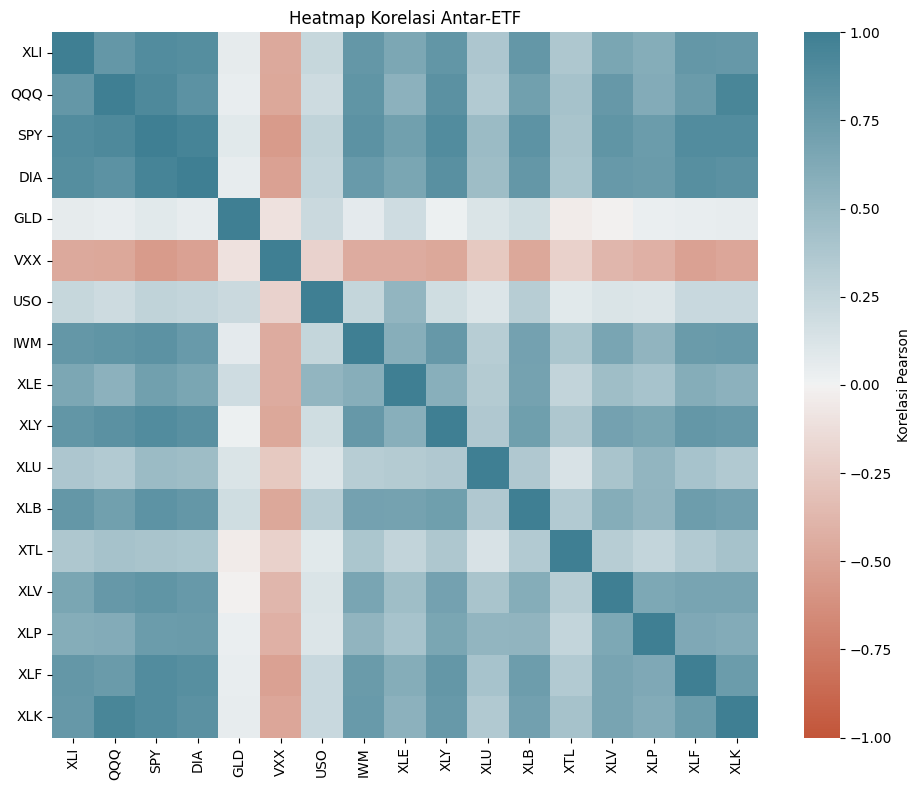

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    vmin=-1,
    vmax=1,
    center=0,
    cmap=sns.diverging_palette(20, 220, as_cmap=True),
    square=True,
    cbar_kws={"label": "Korelasi Pearson"}
)

plt.title("Heatmap Korelasi Antar-ETF")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretasi hasil:**

Kotak pada pasangan **SPY dan DIA** berwarna biru pekat, menunjukkan korelasi positif yang tinggi. Perubahan harga harian kedua ETF tersebut cenderung bergerak searah.

Diagonal grafik juga berwarna biru pekat karena korelasi setiap ETF dengan dirinya sendiri bernilai +1.

Kotak yang mendekati putih menunjukkan hubungan linear yang lebih lemah. Heatmap membantu kita membandingkan arah dan kekuatan hubungan antar-ETF secara visual.

### 7.4 Other Correlation Estimates — Spearman dan Kendall

Selain Pearson, terdapat korelasi berbasis **peringkat**, yaitu urutan nilai dari yang terkecil hingga terbesar.

**Spearman’s rho**

Spearman menghitung korelasi Pearson pada peringkat data. Metode ini mengukur hubungan **monotonik**: ketika X meningkat, Y cenderung terus meningkat atau terus menurun, meskipun polanya melengkung.

**Kendall’s tau**

Kendall membandingkan urutan setiap pasangan pengamatan pada kedua variabel. Pasangan disebut **concordant** jika urutannya searah dan **discordant** jika urutannya berlawanan. Semakin banyak pasangan searah dibandingkan pasangan berlawanan, semakin positif korelasinya.

Kedua koefisien berada antara −1 dan +1. Karena menggunakan peringkat, keduanya lebih tahan terhadap besarnya nilai ekstrem dibandingkan Pearson. Namun, perubahan urutan akibat outlier tetap dapat memengaruhi hasil.

In [24]:
import pandas as pd

x = pd.Series([1, 2, 3, 4, 5])
y = pd.Series([1, 4, 9, 16, 25])

print(f"Pearson: {x.corr(y, method='pearson'):.3f}")
print(f"Spearman: {x.corr(y, method='spearman'):.3f}")
print(f"Kendall: {x.corr(y, method='kendall'):.3f}")

Pearson: 0.981
Spearman: 1.000
Kendall: 1.000


**Interpretasi hasil:**

Pada contoh ini, nilai Y merupakan kuadrat dari X. Untuk nilai X yang digunakan, Y selalu meningkat ketika X meningkat, sehingga hubungan tersebut monotonik naik.

Spearman dan Kendall bernilai **1,000** karena urutan kedua variabel sesuai secara sempurna.

Pearson bernilai sekitar **0,981**, menunjukkan hubungan linear yang kuat. Nilainya kurang dari 1 karena pola hubungan X dan Y melengkung, sehingga titik-titiknya tidak membentuk garis lurus sempurna.

### 7.5 Reproduksi Tabel 1-7 — Korelasi Saham Telekomunikasi

Contoh ini menganalisis lima saham telekomunikasi dalam dataset buku, dengan simbol **T, CTL, FTR, VZ, dan LVLT**.

Setiap baris data mewakili tanggal pengamatan, sedangkan setiap kolom berisi perubahan harga harian suatu saham.

Kita memilih saham yang termasuk sektor telekomunikasi dan data mulai Juli 2012. Selanjutnya, korelasi Pearson dihitung untuk setiap pasangan saham menggunakan pengamatan pada tanggal yang sama.

Matriks ini membantu kita mengetahui saham mana yang perubahan harga hariannya cenderung bergerak searah.

In [26]:
telecom_symbols = sp500_sym.loc[
    sp500_sym["sector"] == "telecommunications_services",
    "symbol"
]

telecom = sp500_px.loc[
    sp500_px.index >= "2012-07-01",
    telecom_symbols
]

telecom_correlation = telecom.corr(method="pearson")

telecom_correlation.round(3)

,T,CTL,FTR,VZ,LVLT
T,1.000,0.475,0.328,0.678,0.279
CTL,0.475,1.000,0.420,0.417,0.287
FTR,0.328,0.420,1.000,0.287,0.260
VZ,0.678,0.417,0.287,1.000,0.242
LVLT,0.279,0.287,0.260,0.242,1.000


**Interpretasi hasil:**

Di antara pasangan saham yang berbeda, **T (AT&T) dan VZ (Verizon)** memiliki korelasi tertinggi, yaitu sekitar **0,678**. Nilai positif ini menunjukkan bahwa perubahan harga harian kedua saham cenderung bergerak searah.

Saham **LVLT** memiliki korelasi yang relatif lebih rendah dengan saham lainnya dalam kelompok tersebut.

Nilai diagonal sebesar 1 menunjukkan korelasi setiap saham dengan dirinya sendiri. Untuk membandingkan hubungan antar-saham, kita membaca nilai di luar diagonal.

### 7.6 Scatterplots — Diagram Pencar

Scatterplot adalah grafik untuk melihat hubungan antara dua variabel numerik. Setiap titik menunjukkan satu pasangan pengamatan.

Dalam contoh ini:

- **Sumbu X:** perubahan harga harian saham AT&T, dengan simbol T.
- **Sumbu Y:** perubahan harga harian saham Verizon, dengan simbol VZ.
- **Setiap titik:** perubahan harga kedua saham pada tanggal yang sama.

Scatterplot membantu kita melihat arah dan bentuk hubungan, pengelompokan data, serta titik yang menyimpang dari pola umum.

Garis horizontal dan vertikal pada nilai nol menjadi penanda untuk membedakan perubahan harga positif (naik) dan negatif (turun).

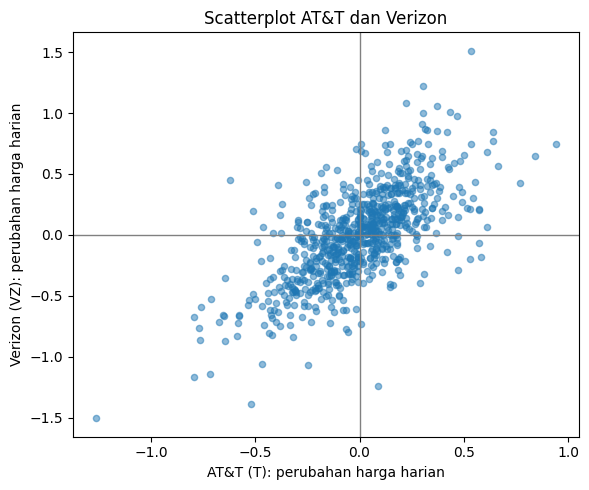

In [27]:
import matplotlib.pyplot as plt

ax = telecom.plot.scatter(
    x="T",
    y="VZ",
    figsize=(6, 5),
    marker="o",
    alpha=0.5
)

ax.set_xlabel("AT&T (T): perubahan harga harian")
ax.set_ylabel("Verizon (VZ): perubahan harga harian")
ax.axhline(0, color="grey", lw=1)
ax.axvline(0, color="grey", lw=1)
ax.set_title("Scatterplot AT&T dan Verizon")

plt.tight_layout()
plt.show()

**Interpretasi hasil:**

Titik-titik mengumpul di sekitar perubahan harga nol dan cenderung membentuk pola dari kiri bawah menuju kanan atas. Pola tersebut menunjukkan hubungan positif antara perubahan harga harian AT&T dan Verizon.

Titik di kanan atas menunjukkan hari ketika kedua saham naik, sedangkan titik di kiri bawah menunjukkan hari ketika keduanya turun.

Pola ini sejalan dengan korelasi Pearson sekitar **0,678** yang dihitung sebelumnya. Titik-titik tetap menyebar, sehingga hubungan keduanya tidak membentuk garis lurus sempurna.

## 8. Exploring Two or More Variables

Analisis data dapat dibedakan berdasarkan jumlah variabel yang diperiksa:

- **Univariat:** satu variabel.
- **Bivariat:** dua variabel.
- **Multivariat:** lebih dari dua variabel.

### 8.1 Hexagonal Binning — Pengelompokan Segi Enam

Ketika jumlah pengamatan sangat besar, titik-titik pada scatterplot dapat bertumpuk. Hexbin plot merangkum pengamatan dalam sel berbentuk segi enam. Warna setiap sel menunjukkan jumlah pengamatan di dalamnya.

Contoh buku menggunakan data properti di King County dengan dua variabel:

- **SqFtTotLiving:** luas ruang hunian dalam kaki persegi.
- **TaxAssessedValue:** nilai taksiran properti untuk keperluan pajak, dalam dolar AS.

Mengikuti contoh buku, kita memilih properti dengan nilai taksiran kurang dari 750.000 dolar AS dan luas hunian lebih dari 100 tetapi kurang dari 3.500 kaki persegi.

Pada palet abu-abu yang digunakan, sel yang semakin gelap menunjukkan semakin banyak pengamatan.

Ukuran data setelah filter: (432693, 3)


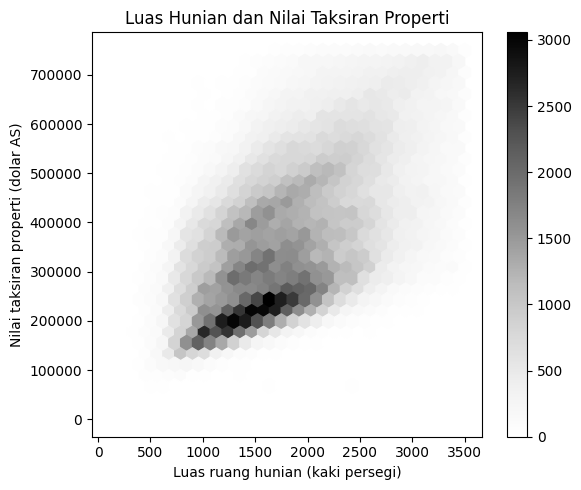

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

url_kc_tax = (
    "https://raw.githubusercontent.com/gedeck/"
    "practical-statistics-for-data-scientists/master/data/kc_tax.csv.gz"
)

kc_tax = pd.read_csv(url_kc_tax, compression="gzip")

kc_tax0 = kc_tax.loc[
    (kc_tax["TaxAssessedValue"] < 750000)
    & (kc_tax["SqFtTotLiving"] > 100)
    & (kc_tax["SqFtTotLiving"] < 3500)
]

print("Ukuran data setelah filter:", kc_tax0.shape)

ax = kc_tax0.plot.hexbin(
    x="SqFtTotLiving",
    y="TaxAssessedValue",
    gridsize=30,
    sharex=False,
    figsize=(6, 5),
    cmap="Greys"
)

ax.set_xlabel("Luas ruang hunian (kaki persegi)")
ax.set_ylabel("Nilai taksiran properti (dolar AS)")
ax.set_title("Luas Hunian dan Nilai Taksiran Properti")

plt.tight_layout()
plt.show()

**Interpretasi hasil:**

Grafik menunjukkan kecenderungan hubungan positif antara luas hunian dan nilai taksiran properti. Hunian yang lebih luas cenderung memiliki nilai taksiran yang lebih tinggi.

Area yang lebih gelap menunjukkan kombinasi luas hunian dan nilai taksiran yang memiliki lebih banyak pengamatan.

Hexbin membantu memperlihatkan pola dan kepadatan data meskipun jumlah pengamatan sangat besar. Interpretasi ini berlaku untuk properti yang memenuhi batas penyaringan.

### 8.2 Contour Plot — Grafik Kontur

Contour plot digunakan untuk melihat pola kepadatan dua variabel numerik. Garis kontur menghubungkan titik-titik yang memiliki **perkiraan kepadatan data yang sama**.

Grafik ini menggunakan **Kernel Density Estimation (KDE)** dua dimensi untuk memperkirakan kepadatan berdasarkan posisi pengamatan. Bayangkan peta topografi: pada grafik ini, garisnya menunjukkan tingkat kepadatan, bukan ketinggian tanah.

Parameter *bandwidth* mengatur penghalusan perkiraan tersebut. Bandwidth besar menghasilkan pola lebih halus, sedangkan bandwidth kecil dapat memperlihatkan rincian sekaligus noise.

Variabel yang digunakan:

- **SqFtTotLiving:** luas ruang hunian dalam kaki persegi.
- **TaxAssessedValue:** nilai taksiran properti untuk keperluan pajak, dalam dolar AS.

Plot menggunakan sampel acak 10.000 baris dari data yang sudah difilter agar perhitungan lebih ringan.

Ukuran sampel: (10000, 3)


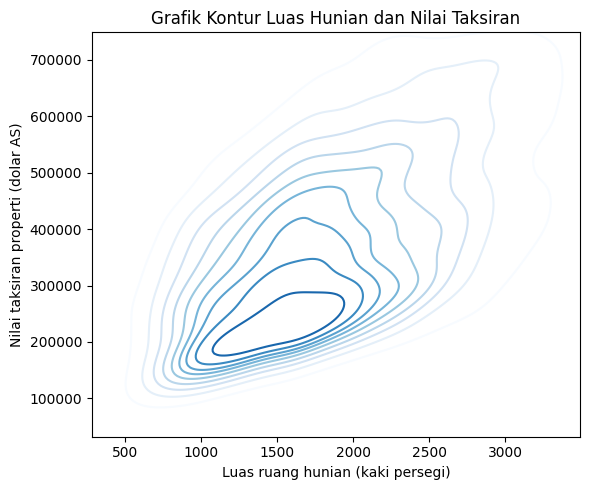

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

contour_sample = kc_tax0.sample(n=10000, random_state=42)
print("Ukuran sampel:", contour_sample.shape)

fig, ax = plt.subplots(figsize=(6, 5))

sns.kdeplot(
    data=contour_sample,
    x="SqFtTotLiving",
    y="TaxAssessedValue",
    levels=10,
    cmap="Blues",
    cut=0,
    ax=ax
)

ax.set_xlabel("Luas ruang hunian (kaki persegi)")
ax.set_ylabel("Nilai taksiran properti (dolar AS)")
ax.set_title("Grafik Kontur Luas Hunian dan Nilai Taksiran")

plt.tight_layout()
plt.show()

#### Interpretasi

Pola kontur cenderung memanjang dari kiri bawah menuju kanan atas. Pola ini menunjukkan bahwa rumah dengan luas hunian lebih besar cenderung memiliki nilai taksiran properti lebih tinggi.

Wilayah dengan perkiraan kepadatan lebih tinggi menunjukkan kombinasi luas hunian dan nilai taksiran yang lebih umum dalam sampel.

Grafik ini menggambarkan pola dari sampel 10.000 rumah yang berasal dari data yang sudah difilter.

### 8.3 Contingency Table — Tabel Kontingensi

Tabel kontingensi merangkum **jumlah pengamatan untuk setiap kombinasi dua variabel kategori**.

Contoh ini menggunakan data pinjaman Lending Club dengan dua variabel:

- **Grade:** peringkat kualitas pinjaman dari A sampai G. A merupakan kualitas tertinggi dan G terendah. Grade termasuk kategori ordinal karena memiliki urutan.
- **Status:** kategori kondisi pembayaran pinjaman.

Status pinjaman dalam data ini meliputi:

- **Charged Off:** saldo pinjaman diperkirakan tidak akan tertagih.
- **Current:** pinjaman masih berjalan dengan pembayaran lancar.
- **Fully Paid:** pinjaman sudah dilunasi.
- **Late:** pembayaran pinjaman terlambat.

Setiap sel tabel menunjukkan jumlah pinjaman dengan kombinasi grade dan status tertentu. Total baris menunjukkan jumlah pinjaman dalam setiap grade, sedangkan total kolom menunjukkan jumlah pinjaman dalam setiap status.

In [30]:
import pandas as pd

url_loans = (
    "https://raw.githubusercontent.com/gedeck/"
    "practical-statistics-for-data-scientists/master/data/lc_loans.csv"
)

lc_loans = pd.read_csv(url_loans)

contingency_table = pd.crosstab(
    lc_loans["grade"],
    lc_loans["status"],
    margins=True
)

print(contingency_table)

status  Charged Off  Current  Fully Paid  Late     All
grade                                                 
A              1562    50051       20408   469   72490
B              5302    93852       31160  2056  132370
C              6023    88928       23147  2777  120875
D              5007    53281       13681  2308   74277
E              2842    24639        5949  1374   34804
F              1526     8444        2328   606   12904
G               409     1990         643   199    3241
All           22671   321185       97316  9789  450961


#### Interpretasi

Pada pertemuan baris A dan kolom Charged Off terdapat angka 1562. Artinya, sebanyak 1.562 pinjaman dengan grade A memiliki status Charged Off.

Grade B memiliki jumlah pinjaman terbanyak, yaitu 132.370 pinjaman, yang terlihat pada kolom All.

Tabel ini menunjukkan jumlah pinjaman pada setiap kombinasi kategori. Untuk membandingkan proporsi status pembayaran antargrade, langkah berikutnya adalah menghitung persentase per baris.

### 8.4 Row Percentages — Persentase per Baris

Persentase per baris menunjukkan pembagian status pembayaran **di dalam setiap grade**. Persentase membantu membandingkan grade yang memiliki jumlah pinjaman berbeda.

Rumusnya:

$$
\text{Persentase status dalam grade}
=
\frac{\text{Jumlah pinjaman dengan status tersebut}}
{\text{Total pinjaman dalam grade tersebut}}
\times 100\%
$$

Jumlah persentase pada empat kolom status dalam setiap baris adalah 100% sebelum pembulatan.

Tabel juga memiliki kolom **Proporsi Grade (%)**. Kolom ini menunjukkan persentase seluruh pinjaman yang termasuk dalam grade tersebut, sehingga pembaginya adalah total seluruh pinjaman.

In [31]:
# Ambil baris grade A–G
grade_counts = contingency_table.loc["A":"G"].copy()

# Hitung persentase status dalam setiap grade
row_percentages = grade_counts.loc[:, "Charged Off":"Late"].div(
    grade_counts["All"], axis=0
) * 100

# Hitung persentase setiap grade dari seluruh pinjaman
row_percentages["Proporsi Grade (%)"] = (
    grade_counts["All"] / contingency_table.loc["All", "All"] * 100
)

print(row_percentages.round(2))

status  Charged Off  Current  Fully Paid  Late  Proporsi Grade (%)
grade                                                             
A              2.15    69.05       28.15  0.65               16.07
B              4.01    70.90       23.54  1.55               29.35
C              4.98    73.57       19.15  2.30               26.80
D              6.74    71.73       18.42  3.11               16.47
E              8.17    70.79       17.09  3.95                7.72
F             11.83    65.44       18.04  4.70                2.86
G             12.62    61.40       19.84  6.14                0.72


#### Interpretasi

Di antara seluruh pinjaman grade A, sekitar 2,15% berstatus Charged Off dan 0,65% berstatus Late.

Persentase Charged Off pada grade G sekitar 12,62%, lebih tinggi daripada grade A. Pada data ini, grade berkualitas lebih rendah cenderung memiliki persentase Charged Off lebih besar.

Nilai 16,07% pada kolom Proporsi Grade berarti pinjaman grade A mencakup sekitar 16,07% dari seluruh pinjaman dalam dataset.

### 8.5 Grouped Boxplot — Boxplot Berdasarkan Kategori

Grouped boxplot digunakan untuk membandingkan distribusi **variabel numerik** pada beberapa kelompok **variabel kategori**.

Contoh ini menggunakan:

- **airline:** nama maskapai, sebagai variabel kategori.
- **pct_carrier_delay:** persentase penerbangan yang terlambat akibat faktor dalam kendali maskapai, sebagai variabel numerik.

Setiap maskapai memiliki satu boxplot. Cara membacanya:

- **Garis dalam kotak:** median.
- **Batas bawah dan atas kotak:** Q1 dan Q3.
- **Tinggi kotak:** IQR, yaitu Q3 − Q1, yang menggambarkan penyebaran bagian tengah data.
- **Whiskers:** mencapai pengamatan terjauh yang masih berada dalam batas Q1 − 1,5 × IQR dan Q3 + 1,5 × IQR.
- **Titik di luar whiskers:** pencilan atau outliers.

Dengan grafik ini, kita dapat membandingkan pusat distribusi, penyebaran, dan pencilan antarmaskapai.

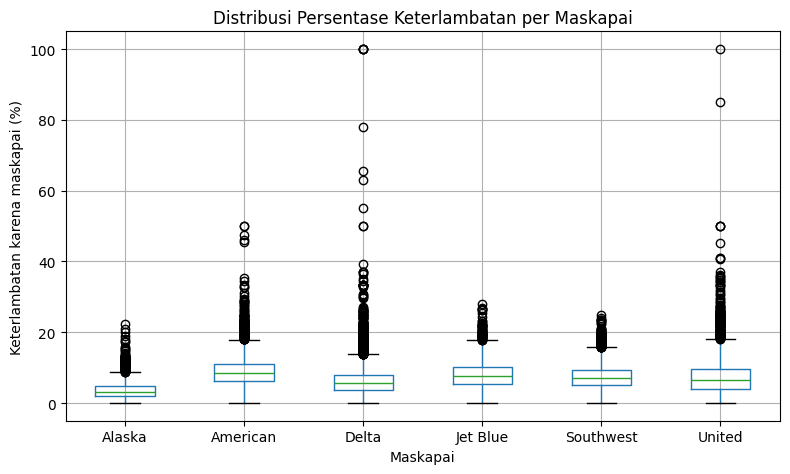

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

url_airline_stats = (
    "https://raw.githubusercontent.com/gedeck/"
    "practical-statistics-for-data-scientists/master/data/airline_stats.csv"
)

airline_stats = pd.read_csv(url_airline_stats)

fig, ax = plt.subplots(figsize=(8, 5))

airline_stats.boxplot(
    column="pct_carrier_delay",
    by="airline",
    ax=ax
)

ax.set_xlabel("Maskapai")
ax.set_ylabel("Keterlambatan karena maskapai (%)")
ax.set_title("Distribusi Persentase Keterlambatan per Maskapai")
plt.suptitle("")

plt.tight_layout()
plt.show()

#### Interpretasi

Pada dataset ini, Alaska memiliki distribusi persentase keterlambatan karena maskapai yang relatif rendah, sedangkan American relatif tinggi.

Q1 American berada di atas Q3 Alaska. Artinya, rentang tengah distribusi American berada lebih tinggi daripada rentang tengah distribusi Alaska.

Perbedaan tinggi kotak menunjukkan perbedaan penyebaran data antarmaskapai. Titik di luar whiskers menunjukkan pengamatan dengan persentase keterlambatan yang jauh dari sebagian besar pengamatan pada maskapai tersebut.

### 8.6 Violin Plot

Violin plot menampilkan bentuk distribusi variabel numerik pada setiap kategori menggunakan **Kernel Density Estimation (KDE)**.

Kurva kepadatan dicerminkan ke kiri dan kanan sehingga bentuknya menyerupai violin atau biola.

Cara membacanya:

- **Bagian yang lebih lebar dalam satu violin:** perkiraan kepadatan lebih tinggi; pengamatan lebih terkonsentrasi di sekitar nilai tersebut.
- **Bagian yang lebih sempit:** perkiraan kepadatan lebih rendah.
- **Tiga garis di dalam violin:** Q1, median, dan Q3.

Bentuk violin membantu memperlihatkan konsentrasi dan puncak distribusi. Boxplot membantu memperlihatkan ringkasan kuartil dan pencilan.

Pada contoh ini, sumbu X menunjukkan maskapai, sedangkan sumbu Y menunjukkan persentase keterlambatan akibat faktor dalam kendali maskapai.

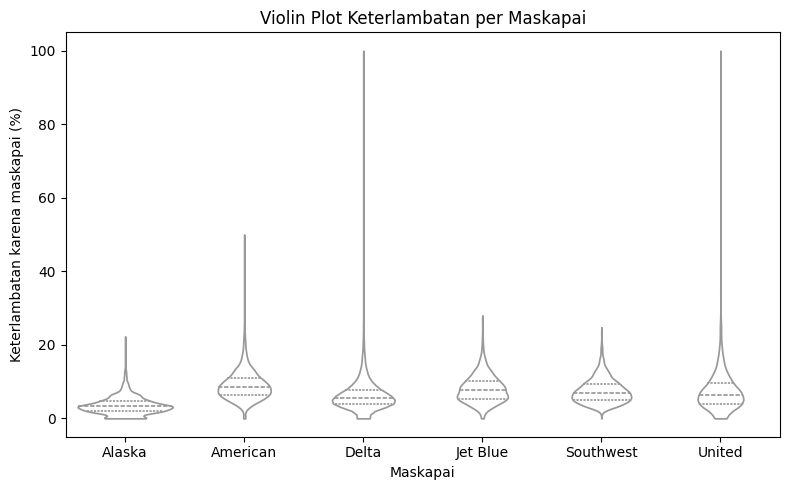

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

sns.violinplot(
    data=airline_stats,
    x="airline",
    y="pct_carrier_delay",
    order=sorted(airline_stats["airline"].dropna().unique()),
    inner="quart",
    color="white",
    cut=0,
    ax=ax
)

ax.set_xlabel("Maskapai")
ax.set_ylabel("Keterlambatan karena maskapai (%)")
ax.set_title("Violin Plot Keterlambatan per Maskapai")

plt.tight_layout()
plt.show()

#### Interpretasi

Violin Alaska menunjukkan konsentrasi pengamatan pada persentase keterlambatan yang rendah, mendekati 0%. Pola serupa juga terlihat pada Delta, meskipun tidak sekuat Alaska.

Bagian yang melebar menunjukkan nilai persentase keterlambatan yang lebih umum dalam distribusi maskapai tersebut.

Perbedaan bentuk violin memperlihatkan bahwa pola distribusi keterlambatan berbeda antarmaskapai.

### 8.7 Visualizing Multiple Variables — Visualisasi Beberapa Variabel

Hubungan dua variabel numerik dapat diperiksa lebih lanjut dengan mengelompokkan data berdasarkan variabel ketiga. Pendekatan ini disebut **conditioning**.

Pada contoh ini, kita menggunakan:

- **SqFtTotLiving:** luas ruang hunian.
- **TaxAssessedValue:** nilai taksiran properti.
- **ZipCode:** kode pos sebagai kategori lokasi. Walaupun ditulis dengan angka, kode pos merupakan label kategori.

Hubungan luas hunian dan nilai taksiran ditampilkan pada panel terpisah untuk setiap kode pos. Pembagian grafik menjadi beberapa panel disebut **faceting**.

Semua panel menggunakan skala sumbu yang sama agar pola antarwilayah mudah dibandingkan. Di dalam setiap panel, heksagon yang lebih gelap menunjukkan jumlah pengamatan lebih banyak. Warna dinormalisasi secara terpisah pada setiap panel.

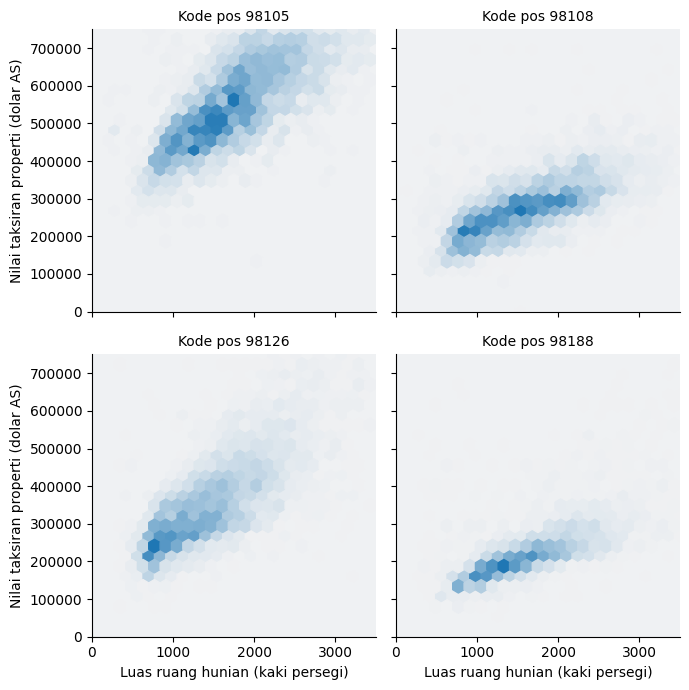

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

zip_codes = [98188, 98105, 98108, 98126]

kc_tax_zip = kc_tax0.loc[
    kc_tax0["ZipCode"].isin(zip_codes)
].copy()


def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x, y, gridsize=25, cmap=cmap, **kwargs)


g = sns.FacetGrid(
    kc_tax_zip,
    col="ZipCode",
    col_order=sorted(zip_codes),
    col_wrap=2,
    height=3.5,
    sharex=True,
    sharey=True
)

g.map(
    hexbin,
    "SqFtTotLiving",
    "TaxAssessedValue",
    extent=[0, 3500, 0, 750000]
)

g.set(xlim=(0, 3500), ylim=(0, 750000))

g.set_axis_labels(
    "Luas ruang hunian (kaki persegi)",
    "Nilai taksiran properti (dolar AS)"
)

g.set_titles("Kode pos {col_name:.0f}")

g.tight_layout()
plt.show()

#### Interpretasi

Pada luas hunian yang serupa, rumah di kode pos 98105 dan 98126 cenderung memiliki nilai taksiran lebih tinggi daripada rumah di kode pos 98108 dan 98188.

Pemisahan berdasarkan kode pos membantu memperlihatkan perbedaan pola antarwilayah yang kurang jelas ketika semua rumah digabung dalam satu grafik.

Temuan ini menunjukkan bahwa lokasi berkaitan dengan variasi nilai taksiran properti dalam data yang sudah difilter.

## 9. Catatan Tambahan tentang Data Kategori

### 9.1 Pie Charts — Diagram Lingkaran

Diagram lingkaran menampilkan proporsi setiap kategori sebagai potongan lingkaran. Seluruh potongan mewakili 100% data yang dirangkum.

Ukuran sudut setiap potongan dihitung dengan:

$$
\text{Sudut potongan} = \text{Proporsi kategori} \times 360^\circ
$$

Sebagai contoh, kategori **Inbound** pada data penyebab keterlambatan mencakup sekitar 42,43% dari total frekuensi penyebab keterlambatan. Kategori ini akan menempati sekitar 42,43% luas lingkaran.

Diagram lingkaran membantu menunjukkan bagian dari keseluruhan. Namun, buku menjelaskan bahwa diagram batang umumnya lebih informatif untuk membandingkan kategori, terutama ketika proporsinya berdekatan.

### 9.2 Numerical Data as Categorical Data — Binning

**Binning** adalah proses mengelompokkan nilai numerik ke dalam interval atau kelas. Interval tersebut kemudian menjadi kategori yang memiliki urutan.

Sebagai contoh konsep, jumlah penduduk dapat dikelompokkan menjadi:

- Sampai dengan 5 juta penduduk.
- Lebih dari 5 juta sampai dengan 10 juta penduduk.
- Lebih dari 10 juta penduduk.

Kategori tersebut bersifat **ordinal** karena urutannya mengikuti besarnya jumlah penduduk.

Pada tabel frekuensi sebelumnya, kita sudah melakukan binning dengan mengelompokkan kolom Population menjadi 10 interval menggunakan `pd.cut`.

Binning membantu menyederhanakan data dan memperlihatkan pola distribusi. Namun, rincian nilai asli berkurang ketika data dirangkum menjadi kategori. Pemilihan jumlah dan batas interval juga dapat memengaruhi pola yang terlihat.

## 10. Ringkasan Chapter 1 — Exploratory Data Analysis

Exploratory Data Analysis (EDA) adalah proses memahami karakteristik data melalui ringkasan statistik dan visualisasi sebelum melakukan analisis atau membangun model.

Konsep utama yang dipelajari dalam chapter ini meliputi:

1. **Struktur dan jenis data:** mengenali data numerik, kategorikal, serta struktur tabel dengan baris sebagai pengamatan dan kolom sebagai variabel.

2. **Ukuran lokasi:** mean, median, trimmed mean, weighted mean, dan weighted median digunakan untuk menggambarkan pusat data. Pemilihannya perlu mempertimbangkan pencilan dan bobot pengamatan.

3. **Ukuran penyebaran:** standar deviasi, IQR, dan ukuran deviasi absolut menggambarkan variasi data. IQR dan median absolute deviation lebih tahan terhadap pencilan dibandingkan standar deviasi.

4. **Distribusi data:** persentil, tabel frekuensi, histogram, boxplot, dan density plot membantu mengenali konsentrasi nilai, kemencengan, penyebaran, dan pencilan.

5. **Data kategori:** frekuensi, proporsi, diagram batang, diagram lingkaran, dan modus merangkum kategori. Expected value menggabungkan nilai kemungkinan hasil dengan probabilitasnya.

6. **Korelasi:** Pearson mengukur hubungan linear, sedangkan Spearman dan Kendall menggunakan peringkat. Korelasi tidak membuktikan hubungan sebab-akibat.

7. **Hubungan beberapa variabel:** scatterplot, hexagonal binning, contour plot, tabel kontingensi, grouped boxplot, violin plot, dan faceting membantu memeriksa hubungan sesuai jenis variabel.

Dalam Machine Learning dan Deep Learning, EDA membantu memahami karakteristik data, menemukan pola awal, dan menentukan kebutuhan persiapan data sebelum membangun model.

## 11. Referensi dan Sumber Reproduksi

**Referensi utama:**

Bruce, P., Bruce, A., & Gedeck, P. (2020). *Practical statistics for data scientists: 50+ essential concepts using R and Python* (2nd ed.). O’Reilly Media.

**Sumber kode dan dataset:**

[Repository pendamping Practical Statistics for Data Scientists](https://github.com/gedeck/practical-statistics-for-data-scientists)

Notebook ini mereproduksi dan mengadaptasi contoh Python dari Chapter 1 untuk dijalankan di Google Colab. Penyesuaian pada fungsi, label grafik, dan penyajian hasil dijelaskan pada bagian terkait. Beberapa latihan tambahan digunakan untuk memperjelas konsep.